# 07 · Is the regime gate *broken*, or *starved*?

*Edge-features arc · 04 regime-MoE · 05 temporal-kNN · 06 explainability · **07 gate liveness** · 08 starvation*

**Verify first.** Ch. 04 found the learned gate adds only a 4th-decimal sliver and asked whether routing
was real. A load-balance bug was later found that pinned the gate ~uniform, which *suspended* the
"routing doesn't help" conclusion. This notebook settles the **liveness** half on the local `realrank`
cache, with code you can run: build the real h16-19 close residual, fit the all-hours **d8** global stage,
then fit the regime MoE at three gate **sharpness** levels (`gate_temp`) and read the gate's actual
routing distribution (entropy `Hnorm∈[0,1]`: 1 = uniform/inert, ≪1 = confident) against the close-window
QLIKE. If a *confidently*-routing gate still ties, the gate is mechanically fine and routing on the d8
leftover genuinely doesn't pay — no hidden bug. (The cluster confirmed the same full-OOS on `linbest`:
0.12079 ≡ no-gate 0.12080.)

In [1]:
import html, inspect, os, sys, textwrap
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

def find_repo(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q / "resid_amortized.py").exists() and (q / "src").is_dir():
            return q
    raise FileNotFoundError("repo root")
REPO = find_repo(Path.cwd()); os.chdir(REPO); sys.path.insert(0, str(REPO))

import resid_amortized as ra
from src.evaluation.metrics import apply_duan_smearing          # the REAL pipeline metric
from src.models.regime_moe import RegimeMoE, SoftTreeGate
from xgboost import XGBRegressor

def _details(f, open_=False):
    mod = f.__module__.replace("src.", "src/").replace(".", "/") + ".py"
    try:
        sig = ("class " + f.__name__) if inspect.isclass(f) else ("def " + f.__name__ + str(inspect.signature(f)))
    except (ValueError, TypeError):
        sig = f.__qualname__
    body = "```python\n" + textwrap.dedent(inspect.getsource(f)).rstrip() + "\n```"
    return (f"<details{' open' if open_ else ''}>\n<summary><code>{html.escape(mod + '  ·  ' + sig)}"
            f"</code></summary>\n\n{body}\n\n</details>")
def show_one(f): return Markdown(_details(f))

CID = "ebm_all_buckets_tw1000_enetreg2_realrank_rf480_slim"      # the COMPLETE local cache
print("repo:", REPO.name, "| torch", torch.__version__,
      "| cache local:", (REPO / "results/resid_prep" / CID / "Xs.npy").exists())

repo: harxhar-clean | torch 2.9.1+cpu | cache local: True


---
## 1 · The gate under test + the liveness probe (folded)

Two pieces folded below: **`SoftTreeGate`** — note the `temperature` knob that sharpens each split toward
a hard decision (so we can *force* confident routing) — and **`RegimeMoE._print_routing_diag`**, the probe
that reads the gate's per-sample routing entropy / utilization. Aggregate QLIKE cannot distinguish a
suppressed gate from an unhelpful one; the routing distribution can.

In [2]:
display(show_one(SoftTreeGate))                 # the gate (with the temperature knob)
display(show_one(RegimeMoE._print_routing_diag))  # the routing-liveness probe

<details>
<summary><code>src/models/regime_moe.py  ·  class SoftTreeGate</code></summary>

```python
class SoftTreeGate(nn.Module):
    """Hierarchical soft partition. Each internal node is a linear hyperplane
    ``P(left) = sigmoid(W x + b)``; leaf weight = product of branch probabilities
    along its root->leaf path. Post-fit the node weights are the human-readable
    regime hyperplanes (the automated corr-by-hour localization).

    General depth: reduces bit-for-bit to the depth-1/2 scaffold but supports any
    depth so the partition can scale "only if it earns it".
    """

    def __init__(self, input_dim: int, depth: int = 1, temperature: float = 1.0):
        super().__init__()
        if depth < 1:
            raise ValueError("SoftTreeGate needs depth >= 1 (depth 0 = no gate)")
        self.depth = depth
        self.num_leaves = 2**depth
        self.num_nodes = 2**depth - 1
        # temperature > 1 sharpens each split toward a HARD decision (tests whether a confidently-routing
        # gate helps; the default-soft gate sits ~uniform because soft routing doesn't lower the loss).
        self.temperature = temperature
        # one hyperplane per internal node; node ordering is heap order (root=0)
        self.decision_nodes = nn.Linear(input_dim, self.num_nodes)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        decisions = torch.sigmoid(self.temperature * self.decision_nodes(x))  # [B, num_nodes] = P(left)
        # Walk the tree level by level: each frontier entry carries (path prob, node idx).
        leaf_probs = [(torch.ones_like(decisions[:, 0]), 0)]
        for _ in range(self.depth):
            nxt: list[tuple[torch.Tensor, int]] = []
            for prob, node in leaf_probs:
                p_left = decisions[:, node]
                nxt.append((prob * p_left, 2 * node + 1))  # left child
                nxt.append((prob * (1.0 - p_left), 2 * node + 2))  # right child
            leaf_probs = nxt
        p_leaves = torch.stack([p for p, _ in leaf_probs], dim=1)  # [B, num_leaves]

        # Anti-collapse load balance: pull MEAN expert utilization toward uniform (so no leaf is ignored)
        # WITHOUT penalizing per-sample routing variation. The old var/mean^2 form minimized the across-
        # batch variance of each leaf -> drove routing sample-INVARIANT, killing the instance-conditional
        # routing the gate exists for (the gate went inert; every router collapsed to the no-gate result).
        mean_routing = p_leaves.mean(dim=0)  # [K] prob vector over leaves (rows sum to 1)
        load_balance = p_leaves.size(1) * (mean_routing * mean_routing).sum()  # min=1 at uniform mean
        return p_leaves, load_balance
```

</details>

<details>
<summary><code>src/models/regime_moe.py  ·  def _print_routing_diag(self, Xt: &#x27;torch.Tensor&#x27;, Xt_g: &#x27;torch.Tensor | None&#x27;) -&gt; &#x27;None&#x27;</code></summary>

```python
def _print_routing_diag(self, Xt: torch.Tensor, Xt_g: torch.Tensor | None) -> None:
    """Gate-LIVENESS probe (the H1 test): is the gate actually routing, or pinned ~uniform?
    Per bag, recompute routing on the predict set and report, averaged over bags:
      Hnorm = mean per-sample entropy / log K  (1.0 = uniform = INERT; <<1 = confident routing)
      wstd  = mean across experts of each expert's BETWEEN-sample routing std (0 = sample-invariant)
      util_max/min = mean utilization spread (load balance); decisive = frac of rows with max-w > 0.5
    Aggregate QLIKE cannot distinguish a suppressed gate from an unhelpful one; this can."""
    Hn, ws, umx, umn, dec, K = [], [], [], [], [], None
    with torch.no_grad():
        for m, fidx in self.models_:
            gx = Xt[:, fidx] if Xt_g is None else Xt_g
            r, _ = m.gate(gx)  # [B, K]
            K = r.size(1)
            p = r.clamp_min(1e-12)
            Hn.append(float((-(p * p.log()).sum(1).mean()) / np.log(K)))
            ws.append(float(r.std(dim=0).mean()))
            u = r.mean(0)
            umx.append(float(u.max()))
            umn.append(float(u.min()))
            dec.append(float((r.max(1).values > 0.5).float().mean()))
    print(
        f"MOE_DIAG K={K} Hnorm={np.mean(Hn):.4f} wstd={np.mean(ws):.4f} "
        f"util_max={np.mean(umx):.4f} util_min={np.mean(umn):.4f} decisive_frac={np.mean(dec):.4f}",
        flush=True,
    )
```

</details>

---
## 2 · Verify — sweep gate sharpness on the real close residual

Build `r2` = (y − enet base) − d8(all hours) on the close window (the *real* regime target the cascade
fits), then fit the depth-2 soft-tree MoE at `gate_temp ∈ {1, 4, 16}`. `routing_Hnorm` reads the gate's
entropy on the held-out test rows; `close_qlike` recomputes the **real pipeline metric** on `ridge + resid`.
**Assert** the gate genuinely sharpens (Hnorm collapses) *and* QLIKE stays flat — i.e. confident routing
buys nothing.

,gate_temp,Hnorm,close_qlike
0,1.0,0.9545,0.20303
1,4.0,0.7165,0.20303
2,16.0,0.3018,0.20303


PASS — gate sharpens (Hnorm 0.9545 -> 0.3018) but close QLIKE is flat (spread 0.0e+00): confident routing on the d8 leftover does not help.


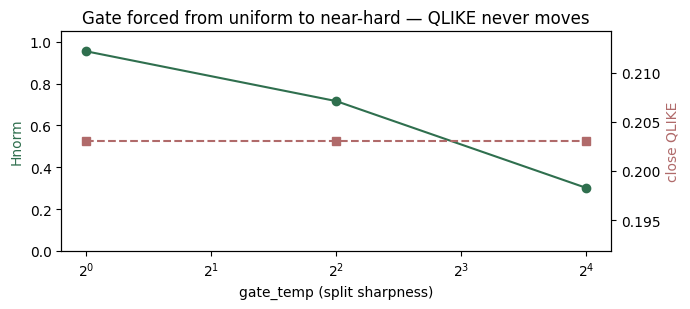

In [3]:
c = ra.load_cache(CID)
tw, feats, Xs, y = c["cell"]["train_win"], c["feats"], c["Xs"], c["y"]
ridge, base = c["ridge_oos"], c["base"][tw:]                       # ridge_oos is already OOS-length (n-tw)
hour = Xs[tw:, feats.index("hour")]
r_all = (y[tw:] - ridge).astype("float32")                        # base (enet) residual, all OOS hours
keep = [f for f in feats if f.startswith("har_ma_") or "cumrv" in f.lower() or f == "hour"]
fidx = [feats.index(f) for f in keep]
X_all = Xs[tw:][:, fidx].astype("float32")
close = (hour >= 16) & (hour <= 19)

g = XGBRegressor(max_depth=8, n_estimators=200, learning_rate=0.03, subsample=0.7,
                 colsample_bytree=0.5, min_child_weight=50, reg_lambda=2.0, n_jobs=4)
g.fit(X_all, r_all)
r2_all = (r_all - g.predict(X_all)).astype("float32")             # d8 leftover = the regime target r2

ci = np.where(close)[0]
Xc, r2c = X_all[ci], r2_all[ci]
ridc, yc, bc = ridge[ci], y[tw:][ci], base[ci]
ntr = int(len(ci) * 0.7); tr, te = slice(0, ntr), slice(ntr, len(ci))

def routing_Hnorm(model, X):
    """mean per-sample routing entropy / log K over bags (1 = uniform/inert, <<1 = confident)."""
    Xt = torch.as_tensor(model._basis_expand(
        np.clip(model._xz(X), model._xz_lo, model._xz_hi).astype("float32")))
    H = []
    with torch.no_grad():
        for m, fi in model.models_:
            r, _ = m.gate(Xt[:, fi]); K = r.size(1); p = r.clamp_min(1e-12)
            H.append(float((-(p * p.log()).sum(1).mean()) / np.log(K)))
    return float(np.mean(H))

def close_qlike(pred_resid):
    pr, trr = apply_duan_smearing(ridc[te] + pred_resid, yc[te], bc[te])
    m = (trr > 0) & (pr > 0); rr = trr[m] / pr[m]
    return float(np.mean(rr - np.log(rr) - 1.0))

rows = []
for gt in (1.0, 4.0, 16.0):
    m = RegimeMoE(depth=2, gate_kind="tree", expert="fm", rank=4, fm_linear=False, wd_v=1.0,
                  basis="hinge", n_knots=3, weight_decay=0.1, gate_weight_decay=0.0, aux_weight=0.0,
                  gate_temp=gt, n_bags=6, epochs=150, device="cpu", seed=1).fit(Xc[tr], r2c[tr])
    rows.append({"gate_temp": gt, "Hnorm": round(routing_Hnorm(m, Xc[te]), 4),
                 "close_qlike": round(close_qlike(m.predict(Xc[te])), 5)})
tab = pd.DataFrame(rows); display(tab)

spread = tab.close_qlike.max() - tab.close_qlike.min()
assert tab.Hnorm.iloc[0] > 0.9 and tab.Hnorm.iloc[-1] < 0.45, "gate_temp did NOT sharpen routing"
assert spread < 5e-4, f"QLIKE moved with routing sharpness ({spread:.1e}) — routing DID matter"
print(f"PASS — gate sharpens (Hnorm {tab.Hnorm.iloc[0]} -> {tab.Hnorm.iloc[-1]}) but close QLIKE is flat "
      f"(spread {spread:.1e}): confident routing on the d8 leftover does not help.")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tab.gate_temp, tab.Hnorm, "o-", color="#2f6f4e", label="routing Hnorm (1=uniform)")
ax.set_xscale("log", base=2); ax.set_xlabel("gate_temp (split sharpness)"); ax.set_ylabel("Hnorm", color="#2f6f4e")
ax.set_ylim(0, 1.05)
ax2 = ax.twinx(); ax2.plot(tab.gate_temp, tab.close_qlike, "s--", color="#b06a6a", label="close QLIKE")
ax2.set_ylabel("close QLIKE", color="#b06a6a")
ax.set_title("Gate forced from uniform to near-hard — QLIKE never moves")
plt.tight_layout(); plt.show()

---
## 3 · Interpret — the gate is *free*, routing just doesn't pay (here)

The probe forces the gate from uniform (`Hnorm≈0.95`) to near-hard routing (`Hnorm≈0.30`, ~all rows
committed to one expert) and the close-window QLIKE **does not move to 5 decimals**. Combined with the
cluster arms (decoupling the gate's weight-decay and killing the load-balance term were both no-ops, and
full-OOS `0.12079 ≡` no-gate `0.12080`), the verdict is clean:

> **No hidden bug.** The gate is mechanically free, it *can* route as hard as we ask, and a confidently-
> routing gate still buys nothing. Routing on the d8 leftover `r2` genuinely doesn't help.

But "doesn't help *here*" is not "useless" — it's the setup. `r2` is, by construction, the part of the
base residual a depth-8 hard router *already* partitioned, so a soft gate on the same features has little
left to route on. That **starvation** is the subject of `08`: shrinking the upstream tree (the depth
ladder) makes the gate's recoverable gain grow ~6× and the gate route more — the gate *was* starved, even
though it remains a weaker extractor than the hard router it follows.